# Generator-truth kinematics: lepton impact parameter, boost, and the production gen filter

**Inputs and selections.** All distributions are generator-level truth from the canonical
`truth_kinematics_forAN` output (180 v10 signal samples, every file, unweighted), channel
**`genOnly`**: status-1 generator leptons as the only object definitions, **no
reconstruction, trigger, or vertex requirements**. Merged files + metadata sidecars:
`/store/group/lpcmetx/SIDM/coffea_outputs/murtazas/truth_kinematics_forAN/`.

**Signal-lepton definition for the impact-parameter figures**: leptons whose direct
generator parent is a dark photon (`genMus_fromA` / `genEs_fromA`). Final-state copies
reached through an FSR chain fall outside this definition (they carry the radiating
lepton, not the dark photon, as direct parent): roughly 20–25% of signal muons and
45–60% of signal electrons, electrons radiating about twice as often as muons (the
per-benchmark numbers are computed below). Since FSR does not alter the production
vertex, the exclusion does not bias the impact-parameter shape, validated in-place
below for both flavors against the inclusive status-1 distributions.

The dark-photon proper-lifetime validation lives in `lifetime_forAN.ipynb`; the
rest-frame/polarization and reconstruction-migration material lives in
`polarization_migration_forAN.ipynb`.


In [1]:
import sys, os, importlib
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

here = os.getcwd()
repo = here.split("/sidm")[0]
for p in (repo, os.path.join(repo, "sidm", "studies", "lifetime_study"),
          os.path.join(repo, "sidm", "studies", "truth_kinematics_forAN")):
    if p not in sys.path:
        sys.path.insert(1, p)
from sidm.tools import utilities
import lifetime_analysis as la
import an_style
importlib.reload(la)

utilities.set_plot_style(dpi=110)
CH = "genOnly"


In [2]:
from _lifetime_refit import load_truthkin
output = load_truthkin()
print(f"loaded {len(output)} samples")

def H(sample, name, channel=CH):
    return output[sample]["hists"][name][{"channel": channel}]

def ctau_label(sample):
    return sample.rsplit("_", 1)[-1].replace("p", ".").replace("mm", " mm")


loaded 180 samples


## Gen-level lepton impact parameter

The trigger (`DoubleL2Mu*NoVtx` seeds) and displaced-muon reconstruction accept or lose
signal as a function of the lepton **transverse impact parameter** `|d0|`, not the decay
radius directly, so `|d0|` is the truth-level variable that connects the lifetime grid to
the trigger and object-selection strategy. Each curve below is one lifetime of the
`mXX = 500 GeV, mZd = 1.2 GeV` benchmark, density-normalized.

Two reading notes: the printed means for the two shortest lifetimes saturate at the
0.05 cm floor set by this histogram's 0.1 cm bin width (dedicated zoom histograms exist
in the output for sub-millimeter work), and at the long end the mean grows more slowly
than cτ because the production filter's decay-volume requirement removes the farthest
decays (see the gen-filter section below and `lifetime_forAN.ipynb`).


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/gen_mu_d0_ctau_scan.pdf
  4Mu_500GeV_1p2GeV_0p019mm: mean |d0| = 0.0500 cm
  4Mu_500GeV_1p2GeV_0p19mm: mean |d0| = 0.0529 cm
  4Mu_500GeV_1p2GeV_1p9mm: mean |d0| = 0.1767 cm
  4Mu_500GeV_1p2GeV_9p6mm: mean |d0| = 0.7183 cm
  4Mu_500GeV_1p2GeV_19p0mm: mean |d0| = 1.0345 cm


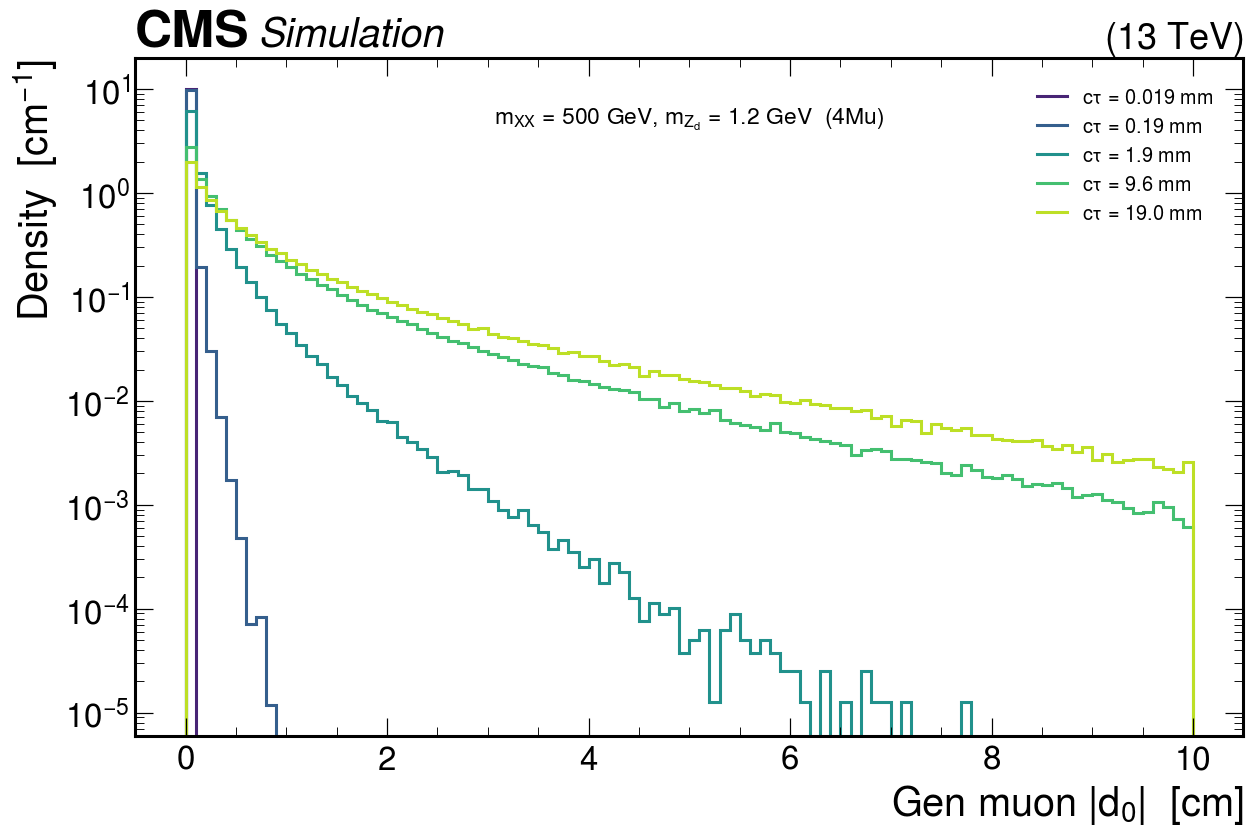

In [3]:
bench_mu = [s for s in sorted(output) if s.startswith("4Mu_500GeV_1p2GeV_")]
fig, ax = plt.subplots(figsize=(13, 8))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(bench_mu)))
means = {}
for s, c in zip(sorted(bench_mu, key=la.ctau_cm), cmap):
    h = H(s, "genMus_fromA_dxy")
    v, e = h.values(), h.axes[-1].edges
    centers = (e[:-1] + e[1:]) / 2
    dens = v / max(v.sum(), 1) / np.diff(e)
    means[s] = (v * centers).sum() / max(v.sum(), 1)
    ax.stairs(dens, e, color=c, lw=2, label=rf"$c\tau$ = {ctau_label(s)}")
ax.set_yscale("log")
ax.set_xlabel(r"Gen muon $|d_0|$  [cm]")
ax.set_ylabel("Density  [cm$^{-1}$]")
ax.text(0.5, 0.93, r"$m_{XX}$ = 500 GeV, $m_{Z_d}$ = 1.2 GeV  (4Mu)",
        transform=ax.transAxes, ha="center", va="top", fontsize=15)
ax.legend(fontsize=13, borderaxespad=1.0)
ax.minorticks_on()
hep.cms.label(ax=ax, data=False)
an_style.save(fig, "gen_mu_d0_ctau_scan")
for s in sorted(bench_mu, key=la.ctau_cm):
    print(f"  {s}: mean |d0| = {means[s]:.4f} cm")


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/gen_e_d0_ctau_scan.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/gen_e_d0_ctau_scan.pdf'

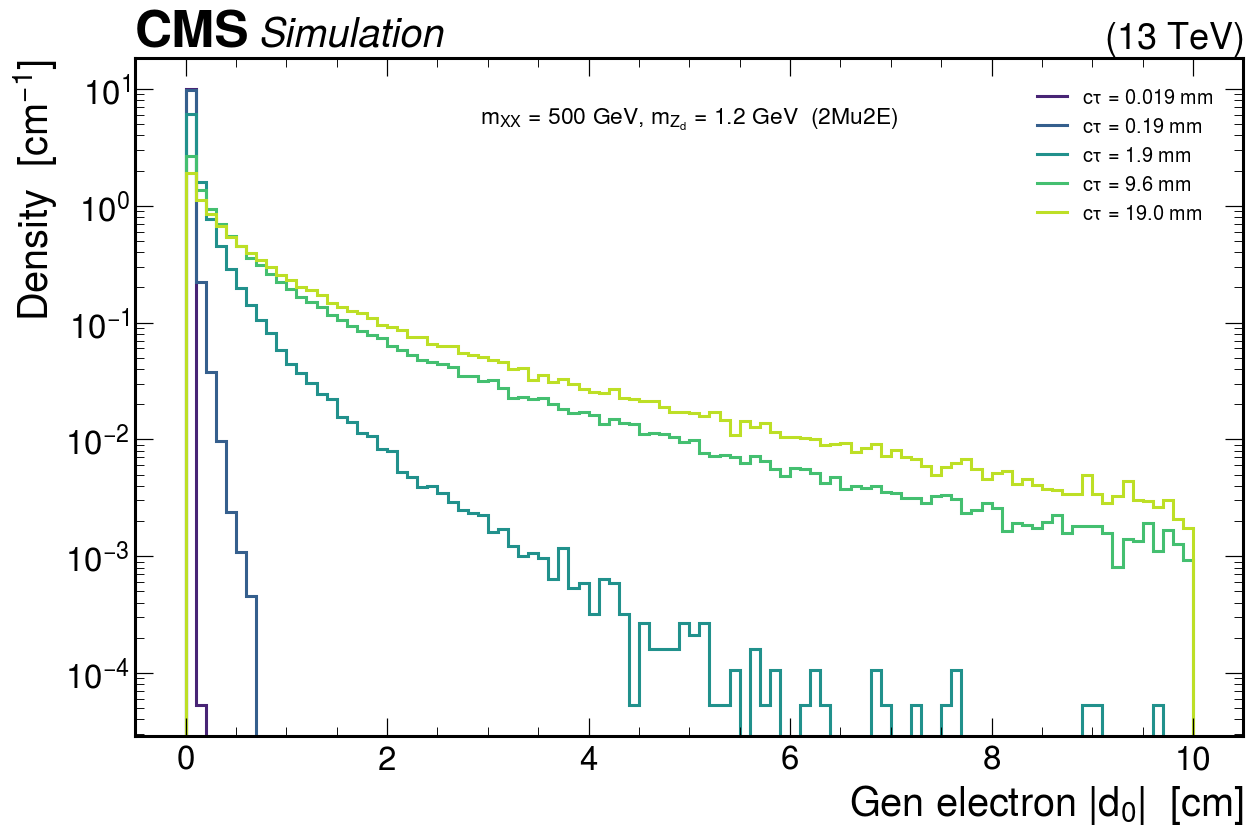

In [4]:
bench_e = [s for s in sorted(output) if s.startswith("2Mu2E_500GeV_1p2GeV_")]
fig, ax = plt.subplots(figsize=(13, 8))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(bench_e)))
for s, c in zip(sorted(bench_e, key=la.ctau_cm), cmap):
    h = H(s, "genEs_fromA_dxy")
    v, e = h.values(), h.axes[-1].edges
    dens = v / max(v.sum(), 1) / np.diff(e)
    ax.stairs(dens, e, color=c, lw=2, label=rf"$c\tau$ = {ctau_label(s)}")
ax.set_yscale("log")
ax.set_xlabel(r"Gen electron $|d_0|$  [cm]")
ax.set_ylabel("Density  [cm$^{-1}$]")
ax.text(0.5, 0.93, r"$m_{XX}$ = 500 GeV, $m_{Z_d}$ = 1.2 GeV  (2Mu2E)",
        transform=ax.transAxes, ha="center", va="top", fontsize=15)
ax.legend(fontsize=13, borderaxespad=1.0)
ax.minorticks_on()
hep.cms.label(ax=ax, data=False)
an_style.save(fig, "gen_e_d0_ctau_scan")


### Kept fractions and shape validation of the signal-lepton definition

First the kept fraction of the direct-parent definition per benchmark (signal leptons
per event are known by construction: four muons in 4Mu; two muons and two electrons in
2Mu2E). Then, for the most displaced benchmark lifetime of each flavor, the inclusive
status-1 distribution (which additionally contains soft underlying-event leptons at
`|d0| ≈ 0` and the FSR-chained signal copies) is overlaid on the direct-parent
selection, both normalized over the displaced region. Shape agreement there
demonstrates the direct-parent definition does not sculpt `|d0|`.


  4Mu_500GeV_1p2GeV_0p019mm: direct-parent muons kept = 0.791
  2Mu2E_500GeV_1p2GeV_0p019mm: direct-parent muons kept = 0.791
  2Mu2E_500GeV_1p2GeV_0p019mm: direct-parent electrons kept = 0.455


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/gen_mu_d0_definition_check.pdf
  4Mu_500GeV_1p2GeV_19p0mm muons: displaced-region shape ratio 16-84% = [0.988 1.022]


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/gen_e_d0_definition_check.pdf
  2Mu2E_500GeV_1p2GeV_19p0mm electrons: displaced-region shape ratio 16-84% = [0.971 1.067]


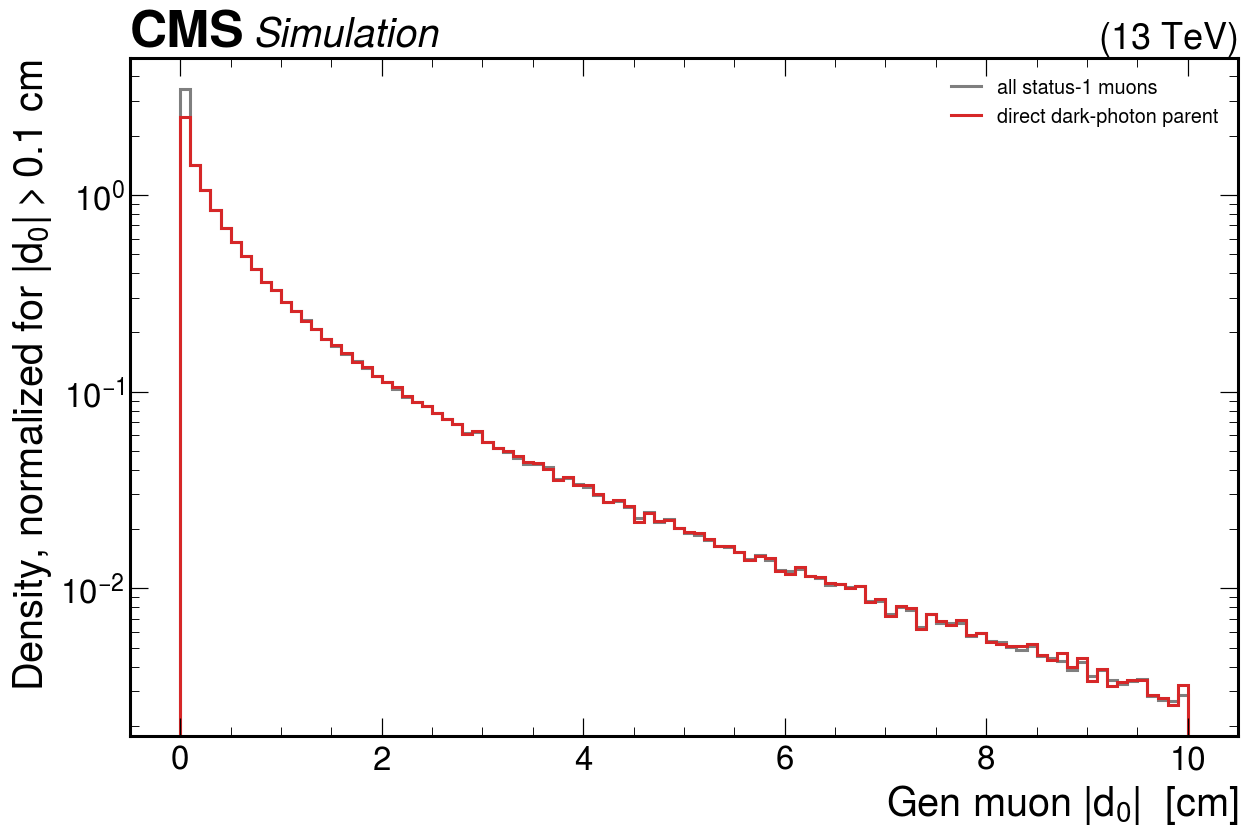

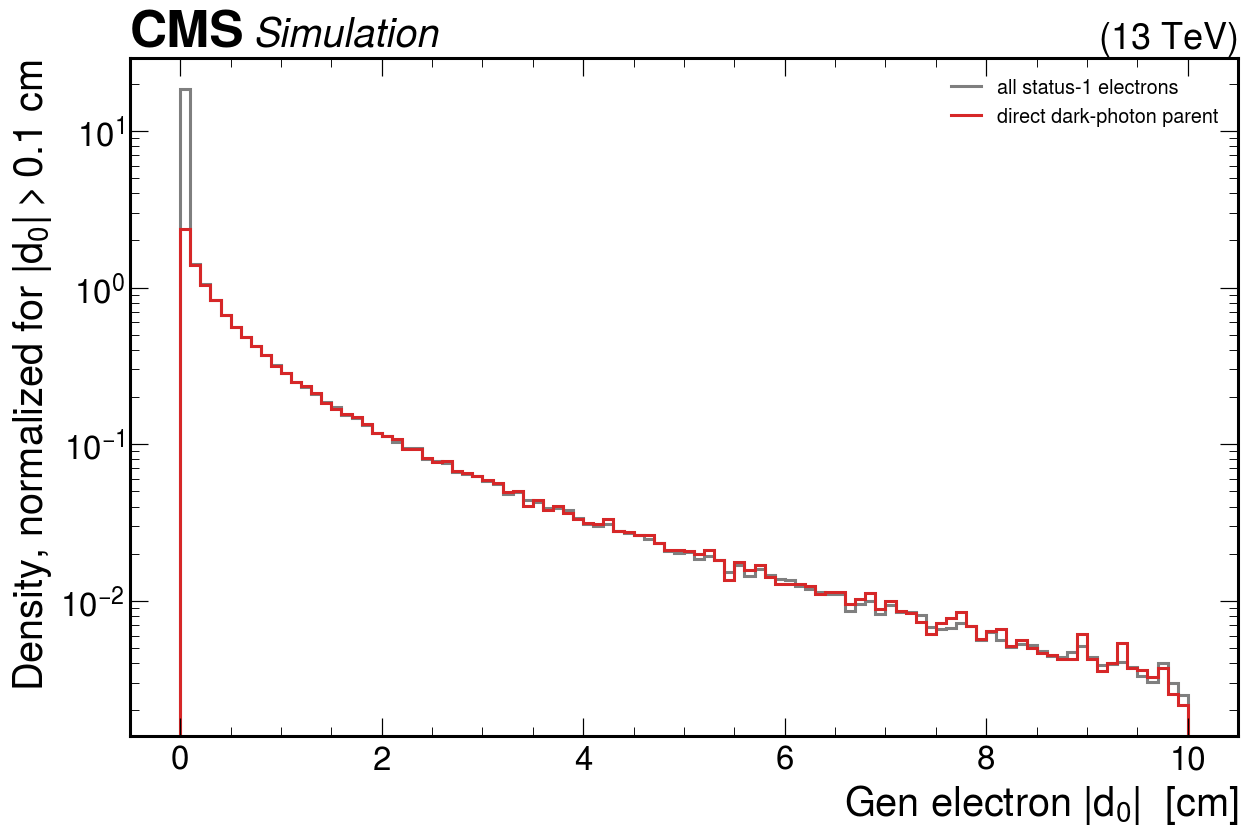

In [5]:
for s, hname, n_sig in [(bench_mu[0], "genMus_fromA_dxy", 4),
                        (bench_e[0], "genMus_fromA_dxy", 2),
                        (bench_e[0], "genEs_fromA_dxy", 2)]:
    n_ev = output[s]["cutflow"][CH].rows["None"]["raw"]
    kept = H(s, hname).values(flow=True).sum() / (n_sig * n_ev)
    flav = "muons" if "Mus" in hname else "electrons"
    print(f"  {s}: direct-parent {flav} kept = {kept:.3f}")

def shape_check(sample, h_from_name, h_all_name, flavor, tag):
    fig, ax = plt.subplots(figsize=(13, 8))
    h_from, h_all = H(sample, h_from_name), H(sample, h_all_name)
    e = h_from.axes[-1].edges
    centers = (e[:-1] + e[1:]) / 2
    disp = centers > 0.1
    for h, lab, c in [(h_all, f"all status-1 {flavor}", "#7f7f7f"),
                      (h_from, "direct dark-photon parent", "#d62728")]:
        v = h.values()
        dens = v / max(v[disp].sum(), 1) / np.diff(e)
        ax.stairs(dens, e, color=c, lw=2, label=lab)
    ax.set_yscale("log")
    ax.set_xlabel(rf"Gen {flavor[:-1]} $|d_0|$  [cm]")
    ax.set_ylabel(r"Density, normalized for $|d_0| > 0.1$ cm")
    ax.legend(fontsize=13)
    ax.minorticks_on()
    hep.cms.label(ax=ax, data=False)
    an_style.save(fig, tag)
    v_a, v_f = h_all.values(), h_from.values()
    if v_a[disp].sum() > 0 and v_f[disp].sum() > 0:
        scaled = v_a[disp] * (v_f[disp].sum() / v_a[disp].sum())
        r = v_f[disp] / np.maximum(scaled, 1e-12)
        r = r[np.isfinite(r) & (r > 0)]
        print(f"  {sample} {flavor}: displaced-region shape ratio 16-84% = "
              f"{np.percentile(r, [16, 84]).round(3)}")
    else:
        print(f"  {sample} {flavor}: displaced region empty, no ratio computed")

shape_check(max(bench_mu, key=la.ctau_cm), "genMus_fromA_dxy", "genMu_dxy",
            "muons", "gen_mu_d0_definition_check")
shape_check(max(bench_e, key=la.ctau_cm), "genEs_fromA_dxy", "genE_dxy",
            "electrons", "gen_e_d0_definition_check")


## Boost across the grid

The mean dark-photon boost `⟨βγ⟩` per mass point spans two orders of magnitude and sets
the lab-frame displacement scale (`Lxy = βγ·cτ`) and the lepton collimation. This single
number per mass point connects the proper-lifetime grid to the
reconstruction-level displacement discussed in the note.


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/gen_betagamma_grid.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/gen_betagamma_grid.pdf'

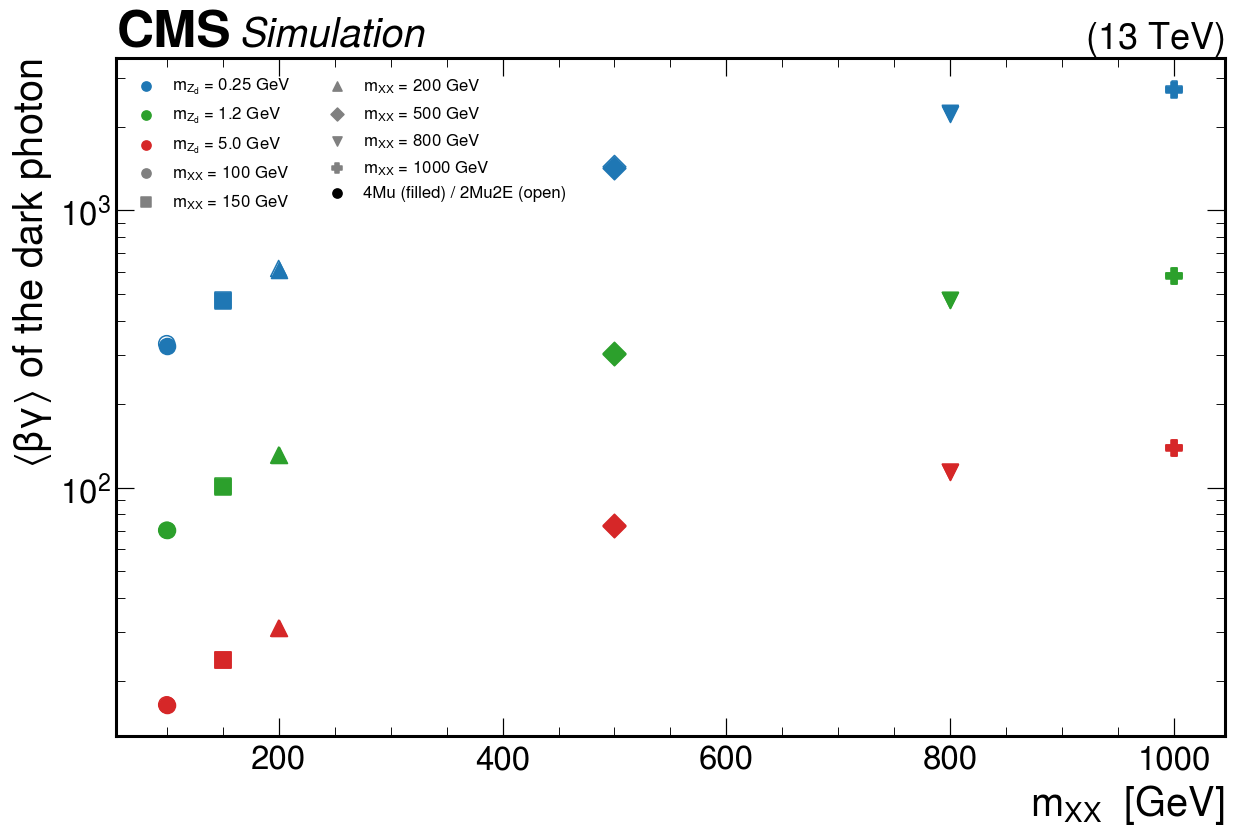

In [6]:
mkr = {"100GeV": "o", "150GeV": "s", "200GeV": "^", "500GeV": "D", "800GeV": "v", "1000GeV": "P"}
col = {"0p25GeV": "#1f77b4", "1p2GeV": "#2ca02c", "5p0GeV": "#d62728"}
fig, ax = plt.subplots(figsize=(13, 8))
seen = set()
for s in sorted(output):
    key = la.mass_point(s)
    if key in seen:
        continue
    seen.add(key)
    anchor = min((x for x in output if la.mass_point(x) == key), key=la.ctau_cm)
    m = utilities.get_hist_mean(H(anchor, "genAs_betagamma"))
    phys, mxx, ma = key
    x = float(mxx.replace("GeV", ""))
    ax.scatter(x, m, marker=mkr[mxx], color=col[ma], s=110,
               facecolors="none" if phys == "2Mu2E" else None)
for ma, c in col.items():
    ax.scatter([], [], color=c,
               label=rf"$m_{{Z_d}}$ = {ma.replace('p', '.').replace('GeV', ' GeV')}")
for mxx, mk in mkr.items():
    ax.scatter([], [], color="gray", marker=mk,
               label=rf"$m_{{XX}}$ = {mxx.replace('GeV', ' GeV')}")
ax.scatter([], [], color="k", label="4Mu (filled) / 2Mu2E (open)")
ax.set_yscale("log")
ax.set_xlabel(r"$m_{XX}$  [GeV]")
ax.set_ylabel(r"$\langle\beta\gamma\rangle$ of the dark photon")
ax.legend(fontsize=11, ncol=2)
ax.minorticks_on()
hep.cms.label(ax=ax, data=False)
an_style.save(fig, "gen_betagamma_grid")


## The production gen filter

Every v10 signal sample was produced **with the central gen filter applied**: at least 4
electrons/muons with `pT > 5 GeV`, `|η| < 2.4`, and production vertex inside
`ρ < 740 cm`, `|z| < 960 cm` (with `isLastCopy && isPromptFinalState &&
fromHardProcessFinalState`). This is recorded in the samples' own `GenFilterInfo`
bookkeeping (e.g. tried 4500 / passed 2325, ε = 0.517, for the retained
`4Mu mXX-500 mZd-1.2 cτ-19 mm` AODSIM), and every kinematic wall in the stored events
sits exactly on these thresholds.

The `genFilterEmulation` channels of this production re-apply the identical cut string.
Because the samples are already filtered, their cutflow is a **re-pass rate** (a
validation that the emulated cut string matches what ran in production) and never a
filter efficiency. The next cell computes it for all 180 samples: it spans 0.84–1.00
with a median near 0.97, lowest at the lightest masses where the leptons sit near the
`pT` threshold. The deficit is fully characterized: in every failing event all four
signal leptons are present and exactly one cut is responsible, the `pT > 5 GeV`
requirement (100% of failing leptons; they cluster at 4.3–4.7 GeV, with η, vertex, and
statusFlags playing no role; measured on the stored generator record by
`_repass_deficit_check.py`, committed alongside this notebook). These borderline leptons were above threshold in the
HepMC-derived record the production filter evaluated and are below it in the stored
`GenPart` copies; the record-level origin of the offset is a production-side question
that does not affect anything quoted here.

The per-point efficiencies plotted below are the values measured on the central
production (`phylsix/Firefighter`, committed here as `central_genFilterEfficiencies.yml`
with provenance in the README); two points were re-measured from scratch with the exact
production configuration and agree (0.8607 ± 0.0035 vs 0.8593; 0.6060 ± 0.0049 vs
0.5994).

**Normalization consequence**: the stored sum of generator weights is *post-filter*, so
any absolute signal normalization must use `σ · ε_filter` (per point, from this table),
not the total cross section alone; otherwise yields are overstated by 1.1–5.2×.


In [7]:
repass = {}
for s in sorted(output):
    for ch in ["genFilterEmulation", "genFilterEmulation_isHardProcess"]:
        rows = {k: v["raw"] for k, v in output[s]["cutflow"][ch].rows.items()}
        names = list(rows)
        repass.setdefault(ch, {})[s] = rows[names[1]] / rows[names[0]]

for ch, vals in repass.items():
    arr = np.array(list(vals.values()))
    print(f"{ch}: re-pass range [{arr.min():.3f}, {arr.max():.3f}], "
          f"median {np.median(arr):.3f}")
print("median re-pass by mXX (McM-variant channel):")
for mxx in ["100GeV", "150GeV", "200GeV", "500GeV", "800GeV", "1000GeV"]:
    sel = [v for s, v in repass["genFilterEmulation"].items() if f"_{mxx}_" in s]
    print(f"  mXX = {mxx:>7}: median {np.median(sel):.3f}  (N={len(sel)})")


genFilterEmulation: re-pass range [0.839, 1.000], median 0.969
genFilterEmulation_isHardProcess: re-pass range [0.845, 1.000], median 0.970
median re-pass by mXX (McM-variant channel):
  mXX =  100GeV: median 0.847  (N=30)
  mXX =  150GeV: median 0.898  (N=30)
  mXX =  200GeV: median 0.923  (N=30)
  mXX =  500GeV: median 0.969  (N=30)
  mXX =  800GeV: median 0.980  (N=30)
  mXX = 1000GeV: median 0.985  (N=30)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/central_filter_efficiency.pdf
central filter efficiency across the grid: mean 0.601, range [0.192, 0.896] over 180 points


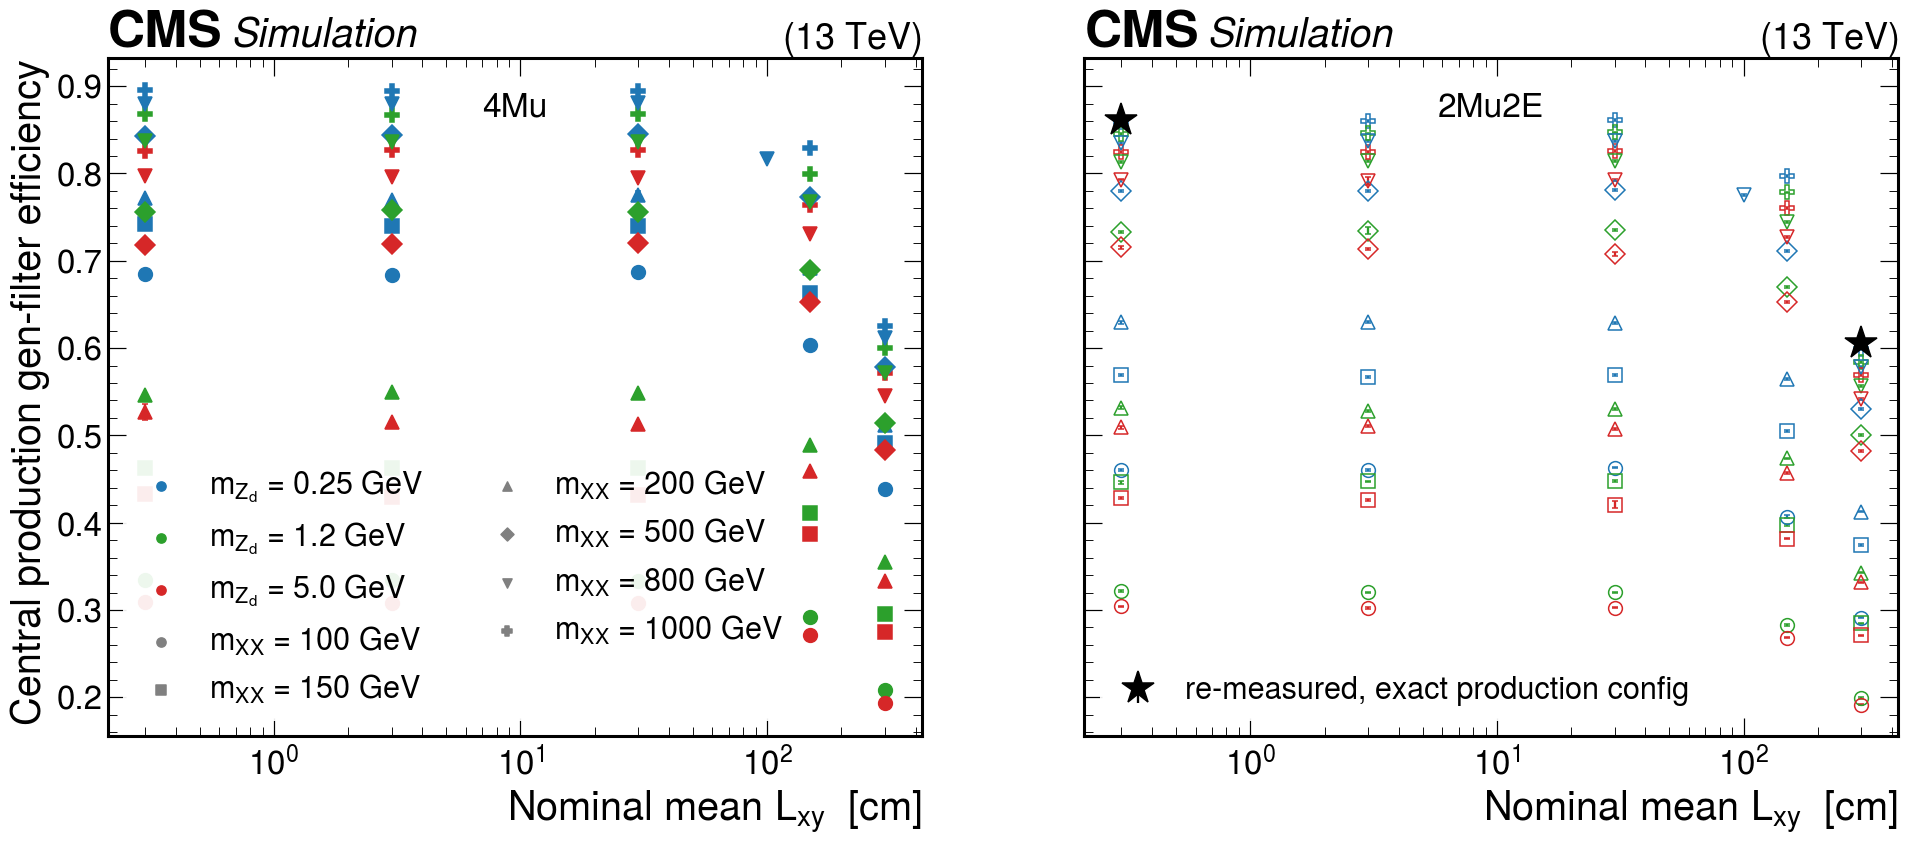

In [8]:
eff = {}
yml = os.path.join(repo, "sidm", "studies", "truth_kinematics_forAN",
                   "central_genFilterEfficiencies.yml")
for line in open(yml):
    line = line.strip()
    if not line or line.startswith("#") or ":" not in line:
        continue
    k, v = line.split(":", 1)
    val, err = v.split("+-")
    eff[k.strip()] = (float(val), float(err))

fig, axes = plt.subplots(1, 2, figsize=(21, 8), sharey=True)
for ax, phys in zip(axes, ["4Mu", "2Mu2E"]):
    for k, (v, err) in eff.items():
        if f"To{phys}_" not in k and not k.startswith(f"XXTo2ATo{phys}"):
            continue
        parts = dict(p.split("-", 1) for p in k.split("_")[1:])
        lxy = float(parts["lxy"].replace("p", "."))
        ma_map = {"0p25": "0p25GeV", "1p2": "1p2GeV", "5": "5p0GeV", "5p0": "5p0GeV"}
        ma = ma_map[parts["mA"]]
        mxx = parts["mXX"]
        ax.errorbar(lxy, v, yerr=err, marker=mkr[mxx + "GeV"], color=col[ma],
                    ms=9, capsize=2, ls="none",
                    markerfacecolor="none" if phys == "2Mu2E" else None)
    ax.set_xscale("log")
    ax.set_xlabel(r"Nominal mean $L_{xy}$  [cm]")
    ax.text(0.5, 0.95, phys, transform=ax.transAxes, ha="center", va="top", fontsize=22)
    ax.minorticks_on()
    hep.cms.label(ax=ax, data=False)
axes[0].set_ylabel("Central production gen-filter efficiency")
for ma, c in col.items():
    axes[0].scatter([], [], color=c,
                    label=rf"$m_{{Z_d}}$ = {ma.replace('p', '.').replace('GeV', ' GeV')}")
for mxx, mk in mkr.items():
    axes[0].scatter([], [], color="gray", marker=mk,
                    label=rf"$m_{{XX}}$ = {mxx.replace('GeV', ' GeV')}")
axes[0].legend(fontsize=20, ncol=2, loc="lower left", frameon=True,
               facecolor="white", edgecolor="none", framealpha=0.92)
axes[1].errorbar([0.3, 300], [0.8607, 0.6060], yerr=[0.0035, 0.0049], marker="*",
                 color="k", ms=22, ls="none", label="re-measured, exact production config")
axes[1].legend(fontsize=20, loc="lower left", frameon=True,
               facecolor="white", edgecolor="none", framealpha=0.92)
an_style.save(fig, "central_filter_efficiency")
vals = [v for v, _ in eff.values()]
print(f"central filter efficiency across the grid: mean {np.mean(vals):.3f}, "
      f"range [{min(vals):.3f}, {max(vals):.3f}] over {len(vals)} points")


## Summary

The truth-level story for the note: the lepton `|d0|` distributions track the lifetime
grid across four orders of magnitude (the variable the trigger and displaced
reconstruction actually see); the dark-photon boost spans `⟨βγ⟩ ≈ 16–2700` across the
mass grid and sets the lab displacement scale; and the samples carry the central
production gen filter, whose per-point efficiency (0.19–0.90) must multiply any absolute
cross-section normalization. Re-applying the filter's cut string to the stored events
passes 0.84–1.00 (median ~0.97), a form validation, not an efficiency. The
proper-lifetime faithfulness of the same samples is established in
`lifetime_forAN.ipynb`.
